1. Download gutenberg corpus using NLTK and list all available text files in it. Choose any
built-in corpus and use appropriate functions to display the list of text files.

In [1]:
import nltk
from nltk.corpus import gutenberg

print(gutenberg.fileids())

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


2. Select a novel from Brown corpus. Tokenize the text into words, generate and display a word
cloud to visualize the most frequent words.

['It/pps', 'would/md', 'have/hv', 'killed/vbn', 'you/ppo', 'in/in', 'the/at', 'cabin/nn', './', '.', 'Do/do', 'you/ppo', 'have/hv', 'anything/pn', 'for/in', 'me/ppo', '``', '/', "''", '?', '/', '.', '?', '/', '.', 'Mercer/np', 'stammered/vbd', ',', '/', ',', 'not/', '*', 'knowing/vbg', 'what/wdt', "B'dikkat/np", 'meant/vbd', ',', '/', ',', 'and/cc', 'the/at', 'two-nosed/jj', 'man/nn', 'answered/vbd', 'for/in', 'him/ppo', ',', '/', ',', '``', '/', '``', 'I/ppss', 'think/vb', 'he/pps', 'has/hvz', 'a/at', 'nice/jj', 'baby/nn', 'head/nn', ',', '/', ',', 'but/cc', 'it/pps', "isn't/bez", '*', 'big/jj', 'enough/qlp', 'for/in', 'you/ppo', 'to/to', 'take/vb', 'yet/rb', '``', '/', "''", './', '.', 'Mercer/np', 'never/rb', 'noticed/vbd', 'the/at', 'needle/nn', 'touch/nn', 'his/pp', '$', 'arm/nn', './', '.', "B'dikkat/np", 'had/hvd', 'turned/vbn', 'to/in', 'the/at', 'next/ap', 'knot/nn', 'of/in', 'people/nns', 'when/wrb', 'the/at', 'super-condamine/nn', 'hit/vbd', 'Mercer/np', './', '.', 'He/pps',

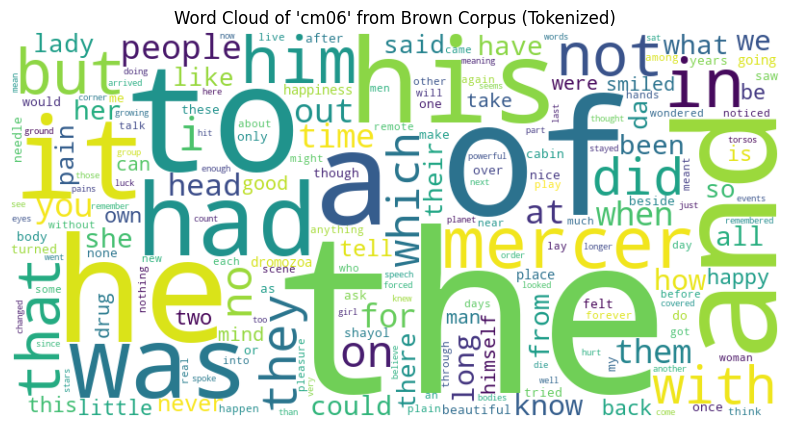

In [12]:
import nltk
from nltk.corpus import brown
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = brown.raw(fileids='cm06')
words = word_tokenize(text)
print(words)

# Remove POS tags and preprocess
words = [word.split('/')[0].lower() for word in words if word.split('/')[0].isalpha()]
print(words)

word_freq = nltk.FreqDist(words)

if not word_freq:
    print("Error: No words left after preprocessing.")
else:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud of 'cm06' from Brown Corpus (Tokenized)")
    plt.show()

3. Select a novel from the gutenberg corpus. Tokenize the text into words, remove stopwords,
and apply lemmatization. Identify the top 15 most frequent words after preprocessing,
visualize the word frequency distribution using a plot.

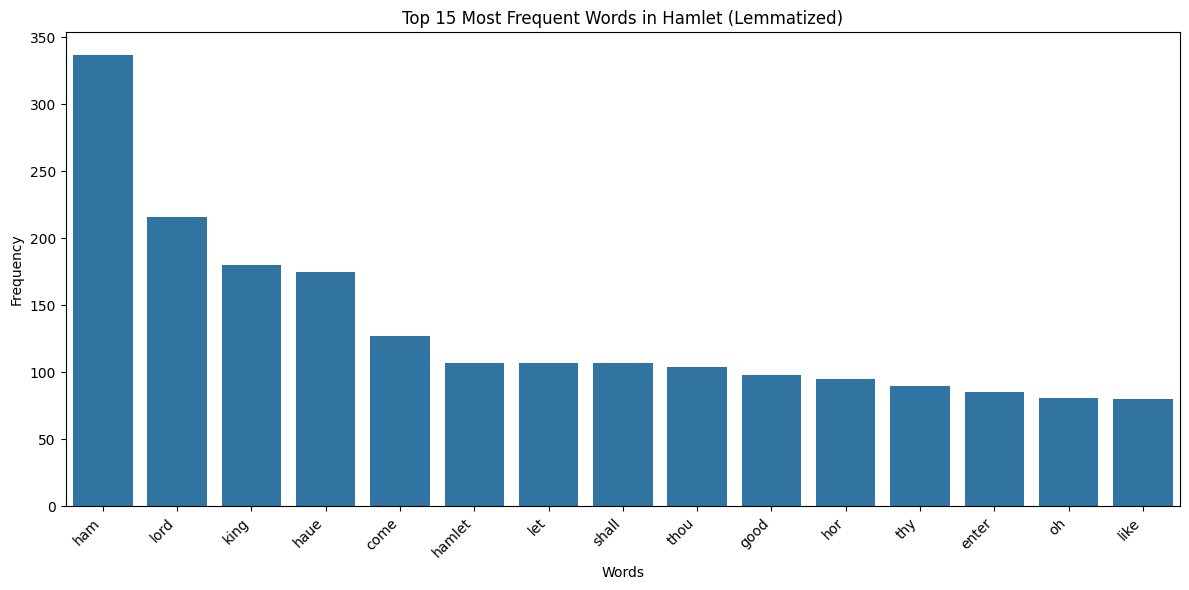

In [ ]:
import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the novel and tokenize
hamlet_novel = gutenberg.raw('shakespeare-hamlet.txt')
tokenized_words = word_tokenize(hamlet_novel)

# 2. Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [word.lower() for word in tokenized_words if word.lower().isalpha() and word.lower() not in stop_words]

# 3. Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]

# 4. Calculate word frequencies
word_freq = nltk.FreqDist(lemmatized_words)

# 5. Get the top 15 most frequent words
top_15 = word_freq.most_common(15)

# 6. Visualize the word frequency distribution
words, frequencies = zip(*top_15)  # Unzip the list of tuples

plt.figure(figsize=(12, 6))
sns.barplot(x=list(words), y=list(frequencies))
plt.title('Top 15 Most Frequent Words in Hamlet (Lemmatized)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

4. Write a program that extracts and prints the 50 most common trigrams (sequences of three
consecutive words) from a text, excluding trigrams that contain stopwords. Use the Brown
corpus as the text source.

In [12]:
import nltk
from nltk.corpus import brown, stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter

# Load the text from the Brown corpus
text = brown.raw(fileids='cm03')
words = word_tokenize(text)

# # Remove POS tags and preprocess
# words = [word.split('/')[0].lower() for word in words if '/' in word and word.split('/')[0].isalpha() or '/' not in word and word.isalpha()]

processed_words = []

for word in words:
    if '/' in word:
        parts = word.split('/')
        actual_word = parts[0] 

        if actual_word.isalpha(): 
            processed_words.append(actual_word.lower())
    else:
        if word.isalpha():
            processed_words.append(word.lower())

words = processed_words

trigrams = list(ngrams(words, 3))


stop_words = set(stopwords.words('english'))
# filtered_trigrams = [
#     trigram for trigram in trigrams
#     if not any(word in stop_words for word in trigram)
# ]

filtered_trigrams = []

for trigram in trigrams:
    contains_stopword = False

    for word in trigram:
        if word in stop_words:
            contains_stopword = True
            break

    if not contains_stopword:
        filtered_trigrams.append(trigram)

trigram_freq = Counter(filtered_trigrams)

most_common_trigrams = trigram_freq.most_common(50)

for trigram, frequency in most_common_trigrams:
    print(f"{trigram}: {frequency}")

('already', 'established', 'premise'): 1
('basic', 'assumptions', 'make'): 1
('angel', 'whose', 'assumptions'): 1
('long', 'pause', 'however'): 1
('already', 'become', 'used'): 1
('snapping', 'back', 'answers'): 1
('jack', 'could', 'get'): 1
('last', 'gabriel', 'spoke'): 1
('galactic', 'center', 'individually'): 1
('essential', 'distinction', 'either'): 1
('distinction', 'either', 'hesperus'): 1
('either', 'hesperus', 'said'): 1
('party', 'gives', 'something'): 1
('instance', 'hesperus', 'agreed'): 1
('much', 'less', 'important'): 1
('less', 'important', 'strange'): 1
('important', 'strange', 'gabriel'): 1
('strange', 'gabriel', 'said'): 1
('apparently', 'impossible', 'though'): 1
('give', 'us', 'hesperus'): 1
('lucifer', 'jack', 'said'): 1
('jack', 'said', 'show'): 1
('alive', 'time', 'yes'): 1
('proper', 'living', 'quarters'): 1
('course', 'agree', 'jack'): 1
('agree', 'jack', 'felt'): 1
('parochial', 'moral', 'judgments'): 1
('applicable', 'earth', 'laws'): 1
('turn', 'would', 'exer

5. Using the Hungarian corpus from NLTK's nltk.corpus.udhr dataset, extract words and identify
their vowel sequences. Construct a bigram table representing the co-occurrence of vowel
pairs. Write a Python program to process the text, extract vowel bigrams, and display the
frequency distribution.

In [14]:
import nltk
from nltk.corpus import udhr
from collections import defaultdict

# Download the Hungarian UDHR corpus
nltk.download('udhr')

# Load the Hungarian UDHR text
hungarian_udhr = udhr.words('Hungarian_Magyar-Latin1')

# Define vowels
vowels = 'aeiouöüóőúéáűí'

# # Function to extract vowel sequences from a word
# def get_vowel_sequence(word):
#     return ''.join(char for char in word.lower() if char in vowels)

# # Extract vowel sequences
# vowel_sequences = [get_vowel_sequence(word) for word in hungarian_udhr if get_vowel_sequence(word)]

def get_vowel_sequence(word):
    """
    This function takes a word as input and returns a string containing only the vowels from that word.
    """
    word_lower = word.lower()  # Convert the word to lowercase to handle both uppercase and lowercase vowels
    vowel_sequence = ""  # Initialize an empty string to store the vowels

    for char in word_lower:  # Loop through each character in the lowercase word
        if char in vowels:  # Check if the character is a vowel (from the 'vowels' string)
            vowel_sequence += char  # If it's a vowel, add it to the vowel_sequence string

    return vowel_sequence  # Return the string containing only the vowels


vowel_sequences = []  # Initialize an empty list to store the vowel sequences

for word in hungarian_udhr:  # Loop through each word in the Hungarian UDHR corpus
    vowel_seq = get_vowel_sequence(word)  # Call the get_vowel_sequence function to get the vowel sequence for the word

    if vowel_seq:  # Check if the vowel sequence is not empty (i.e., the word contains at least one vowel)
        vowel_sequences.append(vowel_seq)  # If it's not empty, add the vowel sequence to the vowel_sequences list

# Extract vowel bigrams
vowel_bigrams = []
for sequence in vowel_sequences:
    if len(sequence) > 1:
        for i in range(len(sequence) - 1):
            vowel_bigrams.append((sequence[i], sequence[i + 1]))

# Construct bigram frequency table
bigram_freq = defaultdict(int)
for bigram in vowel_bigrams:
    bigram_freq[bigram] += 1

# Display bigram frequency distribution
print("Vowel Bigram Frequency Distribution:")
for bigram, frequency in sorted(bigram_freq.items(), key=lambda item: item[1], reverse=True):
    print(f"{bigram}: {frequency}")

Vowel Bigram Frequency Distribution:
('e', 'e'): 284
('é', 'e'): 152
('a', 'a'): 146
('e', 'é'): 129
('i', 'e'): 109
('a', 'á'): 108
('á', 'a'): 91
('o', 'a'): 88
('e', 'i'): 85
('a', 'o'): 64
('á', 'o'): 62
('o', 'á'): 43
('a', 'i'): 40
('á', 'á'): 36
('i', 'a'): 32
('o', 'o'): 29
('é', 'é'): 27
('e', 'ü'): 24
('ö', 'e'): 23
('ü', 'e'): 21
('a', 'e'): 19
('a', 'ó'): 18
('i', 'á'): 17
('u', 'a'): 17
('á', 'i'): 17
('e', 'a'): 16
('é', 'i'): 16
('o', 'i'): 15
('e', 'o'): 14
('ö', 'é'): 14
('ü', 'ö'): 12
('ö', 'ö'): 12
('i', 'o'): 12
('i', 'é'): 10
('e', 'á'): 10
('o', 'í'): 10
('e', 'í'): 9
('e', 'ö'): 9
('á', 'ó'): 9
('ó', 'á'): 8
('i', 'i'): 8
('ü', 'é'): 8
('í', 'e'): 7
('ö', 'i'): 7
('í', 'á'): 7
('é', 'ü'): 7
('é', 'ó'): 6
('u', 'á'): 6
('í', 'ó'): 5
('a', 'u'): 5
('ú', 'á'): 5
('í', 'a'): 5
('a', 'é'): 5
('í', 'é'): 5
('á', 'e'): 5
('á', 'é'): 5
('á', 'í'): 4
('í', 'o'): 4
('a', 'í'): 4
('é', 'í'): 4
('o', 'ó'): 3
('á', 'u'): 3
('ó', 'a'): 3
('u', 'ó'): 3
('ö', 'ü'): 3
('é', 'á'):

[nltk_data] Downloading package udhr to
[nltk_data]     /Users/mdanwarhossain/nltk_data...
[nltk_data]   Package udhr is already up-to-date!
